In [2]:


import os
os.environ['HDF5_USE_FILE_LOCKING'] = 'FALSE'
import h5py
import hdf5plugin  # REQUIRED to have the compression plugins available
import numpy as np
from scipy import constants, interpolate
import copy
import glob
import re
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
pd.set_option('display.max_rows', 1000)
from uvtools.plot import plot_antpos, plot_antclass
from hera_qm import ant_metrics, ant_class, xrfi
from hera_qm import ant_metrics, xrfi
from hera_cal import io, utils, redcal, apply_cal, datacontainer, abscal
from hera_filters import dspec
#from hera_notebook_templates.data import DATA_PATH as HNBT_DATA
from IPython.display import display, HTML
import linsolve
# display(HTML("<style>.container { width:100% !important; }</style>"))
# _ = np.seterr(all='ignore')  # get rid of red warnings
# %config InlineBackend.figure_format = 'retina'



NameError: name 'os' is not defined

In [2]:
import time
tstart = time.time()
!hostname


jake


In [7]:
# figure out whether to save results
SAVE_RESULTS = os.environ.get("SAVE_RESULTS", "TRUE").upper() == "TRUE"
SAVE_OMNIVIS_FILE = os.environ.get("SAVE_OMNIVIS_FILE", "FALSE").upper() == "TRUE"


# get infile names
SUM_FILE = os.environ.get("SUM_FILE", None)
SUM_FILE = '/net/sinatra/vault-ike/ntsikelelo/Data_H6C/single_pol_data_combined_2h.uvh5' # If sum_file is not defined in the environment variables, define it here.
DIFF_FILE = '/net/sinatra/vault-ike/ntsikelelo/Data_H6C/zen.2459861.50015.diff.uvh5'

# get outfilenames
AM_FILE = (SUM_FILE.replace('.uvh5', '.ant_metrics.hdf5') if SAVE_RESULTS else None)
ANTCLASS_FILE = (SUM_FILE.replace('.uvh5', '.ant_class.csv') if SAVE_RESULTS else None)
OMNICAL_FILE = (SUM_FILE.replace('.uvh5', '.omni.calfits') if SAVE_RESULTS else None)
OMNIVIS_FILE = (SUM_FILE.replace('.uvh5', '.omni_vis.uvh5') if SAVE_RESULTS else None)

for fname in ['SUM_FILE', 'DIFF_FILE', 'AM_FILE', 'ANTCLASS_FILE', 'OMNICAL_FILE', 'OMNIVIS_FILE', 'SAVE_RESULTS', 'SAVE_OMNIVIS_FILE']:
    print(f"{fname} = '{eval(fname)}'")

SUM_FILE = '/net/sinatra/vault-ike/ntsikelelo/Data_H6C/single_pol_data_combined_2h.uvh5'
DIFF_FILE = '/net/sinatra/vault-ike/ntsikelelo/Data_H6C/zen.2459861.50015.diff.uvh5'
AM_FILE = '/net/sinatra/vault-ike/ntsikelelo/Data_H6C/single_pol_data_combined_2h.ant_metrics.hdf5'
ANTCLASS_FILE = '/net/sinatra/vault-ike/ntsikelelo/Data_H6C/single_pol_data_combined_2h.ant_class.csv'
OMNICAL_FILE = '/net/sinatra/vault-ike/ntsikelelo/Data_H6C/single_pol_data_combined_2h.omni.calfits'
OMNIVIS_FILE = '/net/sinatra/vault-ike/ntsikelelo/Data_H6C/single_pol_data_combined_2h.omni_vis.uvh5'
SAVE_RESULTS = 'True'
SAVE_OMNIVIS_FILE = 'False'


In [8]:
PLOT = os.environ.get("PLOT", "TRUE").upper() == "TRUE"
if PLOT:
    %matplotlib inline

# parse omnical settings
OC_MAX_DIMS = int(os.environ.get("OC_MAX_DIMS", 4))
OC_MIN_DIM_SIZE = int(os.environ.get("OC_MIN_DIM_SIZE", 8))
OC_SKIP_OUTRIGGERS = os.environ.get("OC_SKIP_OUTRIGGERS", "FALSE").upper() == "TRUE"
OC_MIN_BL_LEN = float(os.environ.get("OC_MIN_BL_LEN", 1))
OC_MAX_BL_LEN = float(os.environ.get("OC_MAX_BL_LEN", 1e100))
OC_MAXITER = int(os.environ.get("OC_MAXITER", 50))
OC_MAX_RERUN = int(os.environ.get("OC_MAX_RERUN", 4))
OC_RERUN_MAXITER = int(os.environ.get("OC_MAXITER", 25))
OC_MAX_CHISQ_FLAGGING_DYNAMIC_RANGE = float(os.environ.get("OC_MAX_CHISQ_FLAGGING_DYNAMIC_RANGE", 1))
OC_USE_PRIOR_SOL = os.environ.get("OC_USE_PRIOR_SOL", "FALSE").upper() == "TRUE"
OC_PRIOR_SOL_FLAG_THRESH = float(os.environ.get("OC_PRIOR_SOL_FLAG_THRESH", .95))
OC_USE_GPU = os.environ.get("SAVE_RESULTS", "FALSE").upper() == "TRUE"

# parse RFI settings
RFI_DPSS_HALFWIDTH = float(os.environ.get("RFI_DPSS_HALFWIDTH", 300e-9))
RFI_NSIG = float(os.environ.get("RFI_NSIG", 4))

# parse abscal settings
ABSCAL_MODEL_FILES_GLOB = os.environ.get("ABSCAL_MODEL_FILES_GLOB", None)
ABSCAL_MIN_BL_LEN = float(os.environ.get("ABSCAL_MIN_BL_LEN", 1.0))
ABSCAL_MAX_BL_LEN = float(os.environ.get("ABSCAL_MAX_BL_LEN", 140.0))
CALIBRATE_CROSS_POLS = os.environ.get("CALIBRATE_CROSS_POLS", "FALSE").upper() == "TRUE"

# print settings
for setting in ['PLOT', 'SAVE_RESULTS', 'OC_MAX_DIMS', 'OC_MIN_DIM_SIZE', 'OC_SKIP_OUTRIGGERS', 
                'OC_MIN_BL_LEN', 'OC_MAX_BL_LEN', 'OC_MAXITER', 'OC_MAX_RERUN', 'OC_RERUN_MAXITER', 
                'OC_MAX_CHISQ_FLAGGING_DYNAMIC_RANGE', 'OC_USE_PRIOR_SOL', 'OC_PRIOR_SOL_FLAG_THRESH', 
                'OC_USE_GPU', 'RFI_DPSS_HALFWIDTH', 'RFI_NSIG', 'ABSCAL_MODEL_FILES_GLOB', 
                'ABSCAL_MIN_BL_LEN', 'ABSCAL_MAX_BL_LEN', "CALIBRATE_CROSS_POLS"]:
    print(f'{setting} = {eval(setting)}')

PLOT = True
SAVE_RESULTS = True
OC_MAX_DIMS = 4
OC_MIN_DIM_SIZE = 8
OC_SKIP_OUTRIGGERS = False
OC_MIN_BL_LEN = 1.0
OC_MAX_BL_LEN = 1e+100
OC_MAXITER = 50
OC_MAX_RERUN = 4
OC_RERUN_MAXITER = 25
OC_MAX_CHISQ_FLAGGING_DYNAMIC_RANGE = 1.0
OC_USE_PRIOR_SOL = False
OC_PRIOR_SOL_FLAG_THRESH = 0.95
OC_USE_GPU = False
RFI_DPSS_HALFWIDTH = 3e-07
RFI_NSIG = 4.0
ABSCAL_MODEL_FILES_GLOB = None
ABSCAL_MIN_BL_LEN = 1.0
ABSCAL_MAX_BL_LEN = 140.0
CALIBRATE_CROSS_POLS = False


In [20]:
read_start = time.time()
hd = io.HERAData(SUM_FILE)
times =np.unique(hd.time_array)[0:2]
data, _, _ = hd.read(times =times)
hd_diff = io.HERAData(DIFF_FILE)
diff_data, _, _ = hd_diff.read(times =times, frequencies=data.freqs)
print(f'Finished loading data in {(time.time() - read_start) / 60:.2f} minutes.')


Finished loading data in 0.33 minutes.


In [21]:
# ant_mepolarization_arraycs bounds for low correlation / dead antennas
am_corr_bad = (0, float(os.environ.get("AM_CORR_BAD", 0.3)))
am_corr_suspect = (float(os.environ.get("AM_CORR_BAD", 0.3)), float(os.environ.get("AM_CORR_SUSPECT", 0.5)))

# ant_metrics bounds for cross-polarized antennas
am_xpol_bad = (-1, float(os.environ.get("AM_XPOL_BAD", -0.1)))
am_xpol_suspect = (float(os.environ.get("AM_XPOL_BAD", -0.1)), float(os.environ.get("AM_XPOL_SUSPECT", 0)))

# bounds on solar altitude (in degrees)
good_solar_altitude = (-90, float(os.environ.get("SUSPECT_SOLAR_ALTITUDE", 0)))
suspect_solar_altitude = (float(os.environ.get("SUSPECT_SOLAR_ALTITUDE", 0)), 90)

# bounds on zeros in spectra
good_zeros_per_eo_spectrum = (0, int(os.environ.get("MAX_ZEROS_PER_EO_SPEC_GOOD", 2)))
suspect_zeros_per_eo_spectrum = (0, int(os.environ.get("MAX_ZEROS_PER_EO_SPEC_SUSPECT", 8)))

# bounds on autocorrelation power
auto_power_good = (float(os.environ.get("AUTO_POWER_GOOD_LOW", 5)), float(os.environ.get("AUTO_POWER_GOOD_HIGH", 30)))
auto_power_suspect = (float(os.environ.get("AUTO_POWER_SUSPECT_LOW", 1)), float(os.environ.get("AUTO_POWER_SUSPECT_HIGH", 60)))

# bounds on autocorrelation slope
auto_slope_good = (float(os.environ.get("AUTO_SLOPE_GOOD_LOW", -0.4)), float(os.environ.get("AUTO_SLOPE_GOOD_HIGH", 0.4)))
auto_slope_suspect = (float(os.environ.get("AUTO_SLOPE_SUSPECT_LOW", -0.6)), float(os.environ.get("AUTO_SLOPE_SUSPECT_HIGH", 0.6)))

# bounds on autocorrelation RFI
auto_rfi_good = (0, float(os.environ.get("AUTO_RFI_GOOD", 1.5)))
auto_rfi_suspect = (0, float(os.environ.get("AUTO_RFI_SUSPECT", 2)))

# bounds on autocorrelation shape
auto_shape_good = (0, float(os.environ.get("AUTO_SHAPE_GOOD", 0.1)))
auto_shape_suspect = (0, float(os.environ.get("AUTO_SHAPE_SUSPECT", 0.2)))

# bound on per-xengine non-noiselike power in diff
bad_xengine_zcut = float(os.environ.get("BAD_XENGINE_ZCUT", 10.0))

# bounds on chi^2 per antenna in omnical
oc_cspa_good = (0, float(os.environ.get("OC_CSPA_GOOD", 10)))
oc_cspa_suspect = (0, float(os.environ.get("OC_CSPA_SUSPECT", 20)))

# print bounds
for bound in ['am_corr_bad', 'am_corr_suspect', 'am_xpol_bad', 'am_xpol_suspect', 
              'good_solar_altitude', 'suspect_solar_altitude',
              'good_zeros_per_eo_spectrum', 'suspect_zeros_per_eo_spectrum',
              'auto_power_good', 'auto_power_suspect', 'auto_slope_good', 'auto_slope_suspect',
              'auto_rfi_good', 'auto_rfi_suspect', 'auto_shape_good', 'auto_shape_suspect',
              'bad_xengine_zcut', 'oc_cspa_good', 'oc_cspa_suspect']:
    print(f'{bound} = {eval(bound)}')

am_corr_bad = (0, 0.3)
am_corr_suspect = (0.3, 0.5)
am_xpol_bad = (-1, -0.1)
am_xpol_suspect = (-0.1, 0.0)
good_solar_altitude = (-90, 0.0)
suspect_solar_altitude = (0.0, 90)
good_zeros_per_eo_spectrum = (0, 2)
suspect_zeros_per_eo_spectrum = (0, 8)
auto_power_good = (5.0, 30.0)
auto_power_suspect = (1.0, 60.0)
auto_slope_good = (-0.4, 0.4)
auto_slope_suspect = (-0.6, 0.6)
auto_rfi_good = (0, 1.5)
auto_rfi_suspect = (0, 2.0)
auto_shape_good = (0, 0.1)
auto_shape_suspect = (0, 0.2)
bad_xengine_zcut = 10.0
oc_cspa_good = (0, 10.0)
oc_cspa_suspect = (0, 20.0)


In [22]:
ants = sorted(set([ant for bl in hd.bls for ant in utils.split_bl(bl)]))
auto_bls = [bl for bl in data if (bl[0] == bl[1]) and (utils.split_pol(bl[2])[0] == utils.split_pol(bl[2])[1])]
antpols = sorted(set([ant[1] for ant in ants]))

In [23]:
# print basic information about the file
print(f'File: {SUM_FILE}')
print(f'JDs: {hd.times} ({np.median(np.diff(hd.times)) * 24 * 3600:.5f} s integrations)')
print(f'LSTS: {hd.lsts * 12 / np.pi } hours')
print(f'Frequencies: {len(hd.freqs)} {np.median(np.diff(hd.freqs)) / 1e6:.5f} MHz channels from {hd.freqs[0] / 1e6:.5f} to {hd.freqs[-1] / 1e6:.5f} MHz')
# print(f'Antennas: {len(hd.data_ants)}')
print(f'Antennas: {len(hd.ants)}')
print(f'Polarizations: {hd.pols}')


File: /net/sinatra/vault-ike/ntsikelelo/Data_H6C/single_pol_data_combined_2h.uvh5
JDs: [2459861.50009578 2459861.50020763 2459861.50031947 2459861.50043132
 2459861.50054317 2459861.50065502 2459861.50076687 2459861.50087871
 2459861.50099056 2459861.50110241 2459861.50121426 2459861.50132611
 2459861.50143796 2459861.5015498  2459861.50166165 2459861.5017735
 2459861.50188535 2459861.5019972  2459861.50210904 2459861.50222089
 2459861.50233274 2459861.50244459 2459861.50255644 2459861.50266828
 2459861.50278013 2459861.50289198 2459861.50300383 2459861.50311568
 2459861.50322752 2459861.50333937 2459861.50345122 2459861.50356307
 2459861.50367492 2459861.50378677 2459861.50389861 2459861.50401046
 2459861.50412231 2459861.50423416 2459861.50434601 2459861.50445785
 2459861.5045697  2459861.50468155 2459861.5047934  2459861.50490525
 2459861.50501709 2459861.50512894 2459861.50524079 2459861.50535264
 2459861.50546449 2459861.50557634 2459861.50568818 2459861.50580003
 2459861.50591188

In [24]:
am = ant_metrics.AntennaMetrics(SUM_FILE, DIFF_FILE, sum_data=data, diff_data=diff_data)
am.iterative_antenna_metrics_and_flagging(crossCut=am_xpol_bad[1], deadCut=am_corr_bad[1])
am.all_metrics = {}  # this saves time and disk by getting rid of per-iteration information we never use
if SAVE_RESULTS:
    am.save_antenna_metrics(AM_FILE, overwrite=True)

All-NaN slice encountered


In [25]:

# Turn ant metrics into classifications
totally_dead_ants = [ant for ant, i in am.xants.items() if i == -1]
am_totally_dead = ant_class.AntennaClassification(good=[ant for ant in ants if ant not in totally_dead_ants], bad=totally_dead_ants)
am_corr = ant_class.antenna_bounds_checker(am.final_metrics['corr'], bad=[am_corr_bad], suspect=[am_corr_suspect], good=[(0, 1)])
am_xpol = ant_class.antenna_bounds_checker(am.final_metrics['corrXPol'], bad=[am_xpol_bad], suspect=[am_xpol_suspect], good=[(-1, 1)])
ant_metrics_class = am_totally_dead + am_corr + am_xpol
if np.all([ant_metrics_class[utils.split_bl(bl)[0]] == 'bad' for bl in auto_bls]):
    raise ValueError('All antennas are flagged for ant_metrics.')

In [26]:
min_sun_alt = np.min(utils.get_sun_alt(hd.times))
solar_class = ant_class.antenna_bounds_checker({ant: min_sun_alt for ant in ants}, good=[good_solar_altitude], suspect=[suspect_solar_altitude])


In [27]:
zeros_class = ant_class.even_odd_zeros_checker(data, diff_data, good=good_zeros_per_eo_spectrum, suspect=suspect_zeros_per_eo_spectrum)
if np.all([zeros_class[utils.split_bl(bl)[0]] == 'bad' for bl in auto_bls]):
    raise ValueError('All antennas are flagged for too many even/odd zeros.')



In [28]:

overall_class =  zeros_class  + solar_class



In [29]:
def array_class_plot(cls, extra_label=""):
    outriggers = [ant for ant in hd.data_ants if ant >= 320]

    if len(outriggers) > 0:
        fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=100, gridspec_kw={'width_ratios': [2, 1]})
        plot_antclass(hd.antpos, cls, ax=axes[0], ants=[ant for ant in hd.data_ants if ant < 320], legend=False, title=f'HERA Core{extra_label}')
        plot_antclass(hd.antpos, cls, ax=axes[1], ants=outriggers, radius=50, title='Outriggers')
    else:
        fig, axes = plt.subplots(1, 1, figsize=(9, 6), dpi=100)
        plot_antclass(hd.antpos, cls, ax=axes, ants=[ant for ant in hd.data_ants if ant < 320], legend=False, title=f'HERA Core{extra_label}')



Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


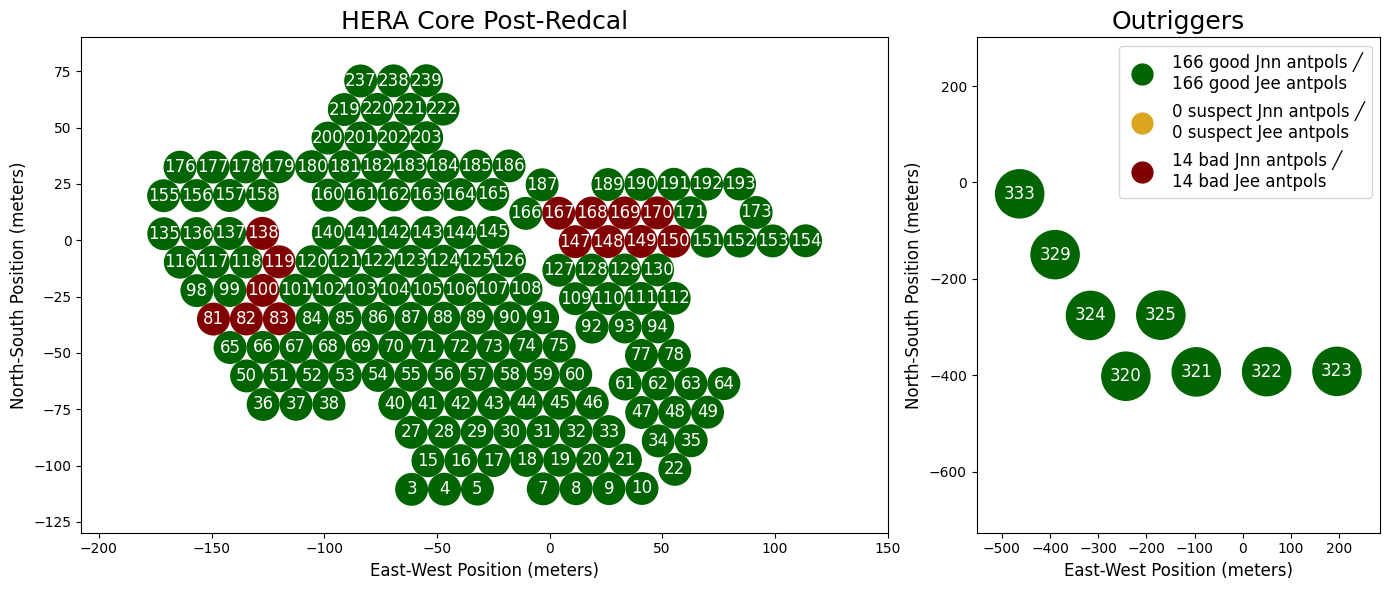

In [30]:

def array_class_plot(cls, extra_label=""):
    outriggers = [ant for ant in hd.data_ants if ant >= 320]

    if len(outriggers) > 0:
        fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=100, gridspec_kw={'width_ratios': [2, 1]})
        plot_antclass(hd.antpos, cls, ax=axes[0], ants=[ant for ant in hd.data_ants if ant < 320], legend=False, title=f'HERA Core{extra_label}')
        plot_antclass(hd.antpos, cls, ax=axes[1], ants=outriggers, radius=50, title='Outriggers')
    else:
        fig, axes = plt.subplots(1, 1, figsize=(9, 6), dpi=100)
        plot_antclass(hd.antpos, cls, ax=axes, ants=[ant for ant in hd.data_ants if ant < 320], legend=False, title=f'HERA Core{extra_label}')


if PLOT: array_class_plot(overall_class, extra_label=" Post-Redcal")

In [31]:


antenna_flags, array_flags = xrfi.flag_autos(data, flag_method="channel_diff_flagger", nsig=RFI_NSIG * 5, 
                                             antenna_class=overall_class, flag_broadcast_thresh=.5)
for key in antenna_flags:
    antenna_flags[key] = array_flags
cache = {}
_, array_flags = xrfi.flag_autos(data, freqs=data.freqs, flag_method="dpss_flagger",
                                 nsig=RFI_NSIG, antenna_class=overall_class,
                                 filter_centers=[0], filter_half_widths=[RFI_DPSS_HALFWIDTH],
                                 eigenval_cutoff=[1e-9], flags=antenna_flags, mode='dpss_matrix', 
                                 cache=cache, flag_broadcast_thresh=.5)



Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


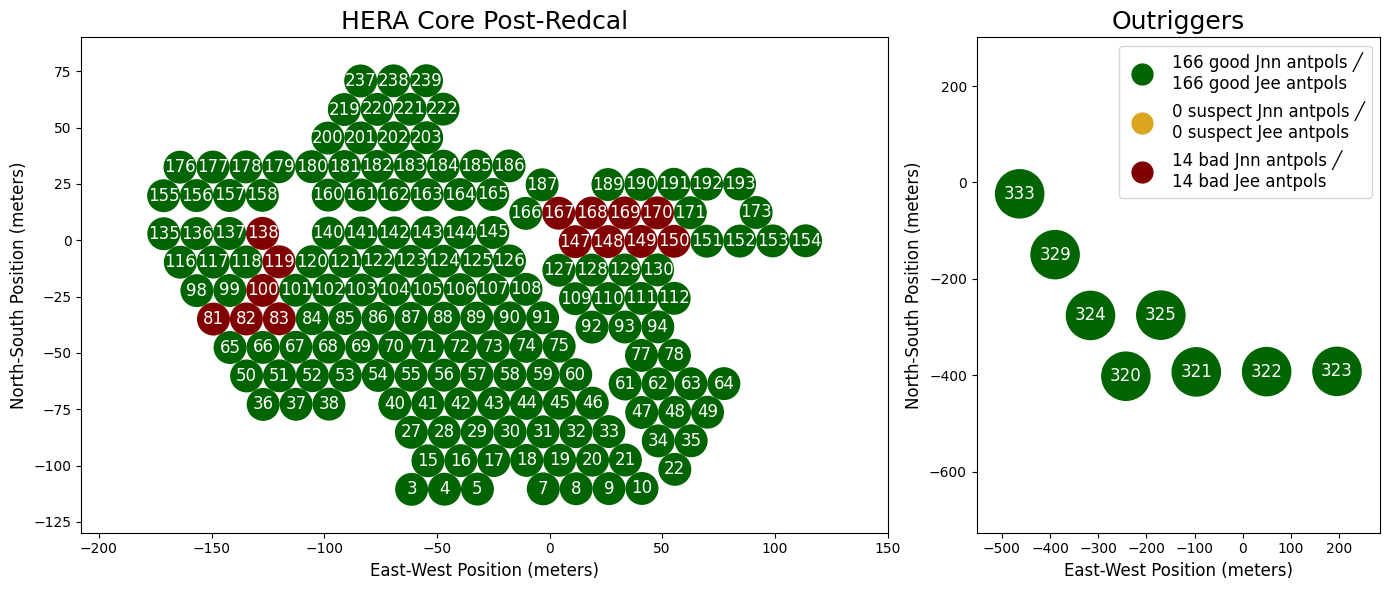

In [32]:
def array_class_plot(cls, extra_label=""):
    outriggers = [ant for ant in hd.data_ants if ant >= 320]

    if len(outriggers) > 0:
        fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=100, gridspec_kw={'width_ratios': [2, 1]})
        plot_antclass(hd.antpos, cls, ax=axes[0], ants=[ant for ant in hd.data_ants if ant < 320], legend=False, title=f'HERA Core{extra_label}')
        plot_antclass(hd.antpos, cls, ax=axes[1], ants=outriggers, radius=50, title='Outriggers')
    else:
        fig, axes = plt.subplots(1, 1, figsize=(9, 6), dpi=100)
        plot_antclass(hd.antpos, cls, ax=axes, ants=[ant for ant in hd.data_ants if ant < 320], legend=False, title=f'HERA Core{extra_label}')


if PLOT: array_class_plot(overall_class, extra_label=" Post-Redcal")

In [33]:
hd_flagged=copy.deepcopy(hd)
data_flagged,_,_=hd_flagged.build_datacontainers()
for bls in data:
    if not overall_class[utils.split_bl(bls)[0]]=='bad':
        data_flagged[bls]=np.array(data[bls])
        data_flagged[bls][np.where(array_flags==True)]=np.nan
        
        
    else:
       
        data_flagged[bls]=np.ones(data[bls].shape)*np.nan

## Perform redundant cal

In [34]:
def classify_off_grid(reds, all_ants):
    '''Returns AntennaClassification of all_ants where good ants are in reds while bad ants are not.'''
    ants_in_reds = set([ant for red in reds for bl in red for ant in utils.split_bl(bl)])
    on_grid = [ant for ant in all_ants if ant in ants_in_reds]
    off_grid = [ant for ant in all_ants if ant not in ants_in_reds]
    return ant_class.AntennaClassification(good=on_grid, bad=off_grid)

In [35]:
def per_pol_filter_reds(reds, pols=['nn', 'ee'], **kwargs):
    '''Performs redcal filtering separately on polarizations (which might have different min_dim_size issues).'''
    return [red for pol in pols for red in redcal.filter_reds(copy.deepcopy(reds), pols=[pol], **kwargs)]

In [36]:
def check_if_whole_pol_flagged(redcal_class, pols=['Jee', 'Jnn']):
    '''Checks if an entire polarization is flagged. If it is, returns True and marks all antennas as bad in redcal_class.'''
    if np.logical_or(*[np.all([redcal_class[ant] == 'bad' for ant in redcal_class.ants if ant[1] == pol]) for pol in pols]):
        print('An entire polarization has been flagged. Stopping redcal.')
        for ant in redcal_class:
            redcal_class[ant] = 'bad'
        return True
    return False

In [37]:


def recheck_chisq(cspa, sol, cutoff, avg_alg, rfi_flags):
    '''Recompute chisq per ant without apparently bad antennas to see if any antennas get better.'''
    avg_cspa = {ant: avg_alg(np.where(rfi_flags, np.nan, cspa[ant])) for ant in cspa}
    sol2 = redcal.RedSol(sol.reds, gains={ant: sol[ant] for ant in avg_cspa if avg_cspa[ant] <= cutoff}, vis=sol.vis)
    new_chisq_per_ant = {ant: np.array(cspa[ant]) for ant in sol2.gains}
    if len(set([bl[2] for red in per_pol_filter_reds(sol2.reds, ants=sol2.gains.keys(), antpos=hd.data_antpos, **fr_settings) for bl in red])) >= 2:
        redcal.expand_omni_gains(sol2, sol2.reds, data, chisq_per_ant=new_chisq_per_ant)
    for ant in avg_cspa:
        if ant in new_chisq_per_ant:
            if np.any(np.isfinite(new_chisq_per_ant[ant])):
                if not np.all(np.isclose(new_chisq_per_ant[ant], 0)):
                    new_avg_cspa = avg_alg(np.where(rfi_flags, np.nan, cspa[ant]))
                    if new_avg_cspa > 0:
                        avg_cspa[ant] = np.min([avg_cspa[ant], new_avg_cspa])
    return avg_cspa



In [38]:

# figure out and filter reds and classify antennas based on whether or not they are on the main grid
fr_settings = {'max_dims': OC_MAX_DIMS, 'min_dim_size': OC_MIN_DIM_SIZE, 'min_bl_cut': OC_MIN_BL_LEN, 'max_bl_cut': OC_MAX_BL_LEN}
reds = redcal.get_reds(hd.data_antpos, pols=['ee', 'nn'], pol_mode='2pol')
reds = per_pol_filter_reds(reds, ex_ants=overall_class.bad_ants, antpos=hd.data_antpos, **fr_settings)
if OC_SKIP_OUTRIGGERS:
    reds = redcal.filter_reds(reds, ex_ants=[ant for ant in ants if ant[0] >= 320])
redcal_class = classify_off_grid(reds, ants)



In [39]:
redcal_start = time.time()
rc_settings = {'max_dims': OC_MAX_DIMS, 'oc_conv_crit': 1e-10, 'gain': 0.4, 'run_logcal': False,
               'oc_maxiter': OC_MAXITER, 'check_after': OC_MAXITER, 'use_gpu': OC_USE_GPU}


# perform first stage of redundant calibration 

meta, sol = redcal.redundantly_calibrate(data, reds, **rc_settings)
max_dly = np.max(np.abs(list(meta['fc_meta']['dlys'].values())))  # Needed for RFI delay-slope cal
median_cspa = recheck_chisq(meta['chisq_per_ant'], sol, oc_cspa_suspect[1] * 5, np.nanmedian, array_flags)
 # remove particularly bad antennas (5x the bound on median, not mean)
cspa_class = ant_class.antenna_bounds_checker(median_cspa, good=(oc_cspa_good[0], oc_cspa_suspect[1] * 5), bad=[(-np.inf, np.inf)])
redcal_class += cspa_class
print(f'Removing {cspa_class.bad_ants} for >5x high median chi^2.')
for ant in cspa_class.bad_ants:
    print(f'\t{ant}: {median_cspa[ant]:.3f}')

#malloc_trim()

Removing set() for >5x high median chi^2.


In [40]:


# this enables better memory management on linux
import ctypes
def malloc_trim():
    try:
        ctypes.CDLL('libc.so.6').malloc_trim(0) 
    except OSError:
        pass



In [41]:
# iteratively rerun redundant calibration
redcal_done = False
rc_settings['oc_maxiter'] = rc_settings['check_after'] = OC_RERUN_MAXITER
for i in range(OC_MAX_RERUN + 1):
    # refilter reds and update classification to reflect new off-grid ants, if any
    reds = per_pol_filter_reds(reds, ex_ants=(overall_class + redcal_class).bad_ants, antpos=hd.data_antpos, **fr_settings)
    reds = sorted(reds, key=len, reverse=True)
    redcal_class += classify_off_grid(reds, ants)
    ants_in_reds = set([ant for red in reds for bl in red for ant in utils.split_bl(bl)])
    
    # check to see whether we're done
    if redcal_done or (i == OC_MAX_RERUN):
        break

    # re-run redundant calibration using previous solution, updating bad and suspicious antennas
    meta, sol = redcal.redundantly_calibrate(data, reds, sol0=sol, **rc_settings)
    malloc_trim()
    
    # recompute chi^2 for bad antennas without bad antennas to make sure they are actually bad
    mean_cspa = recheck_chisq(meta['chisq_per_ant'], sol, oc_cspa_suspect[1], np.nanmean,  array_flags)
    
    # remove bad antennas
    cspa_class = ant_class.antenna_bounds_checker(mean_cspa, good=oc_cspa_good, suspect=oc_cspa_suspect, bad=[(-np.inf, np.inf)])
    for ant in cspa_class.bad_ants:
        if mean_cspa[ant] < np.max(list(mean_cspa.values())) / OC_MAX_CHISQ_FLAGGING_DYNAMIC_RANGE:
            cspa_class[ant] = 'suspect'  # reclassify as suspect if they are much better than the worst antennas
    redcal_class += cspa_class
    print(f'Removing {cspa_class.bad_ants} for high mean unflagged chi^2.')
    for ant in cspa_class.bad_ants:
        print(f'\t{ant}: {mean_cspa[ant]:.3f}')

    if len(cspa_class.bad_ants) == 0:
        redcal_done = True  # no new antennas to flag

print(f'Finished redcal in {(time.time() - redcal_start) / 60:.2f} minutes.')





Removing {(239, 'Jee')} for high mean unflagged chi^2.
	(239, 'Jee'): 152019.586
Removing {(333, 'Jee')} for high mean unflagged chi^2.
	(333, 'Jee'): 28.310
Removing set() for high mean unflagged chi^2.
Finished redcal in 17.38 minutes.


In [42]:
overall_class += redcal_class

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


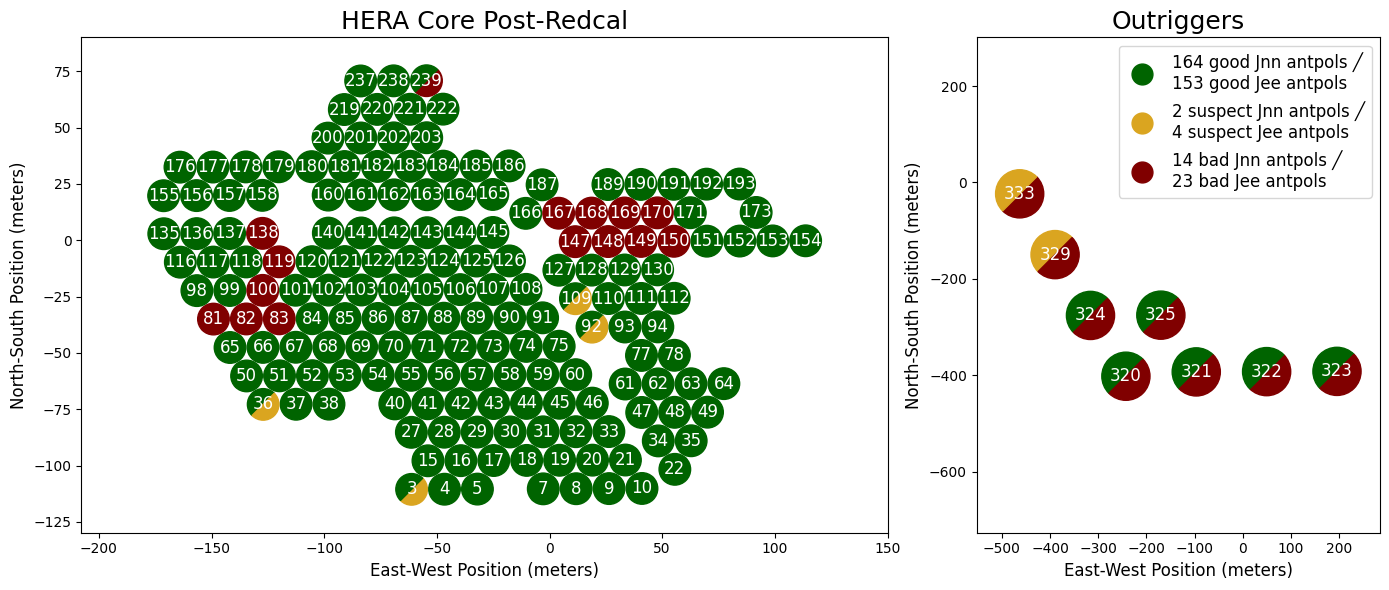

In [43]:
if PLOT: array_class_plot(overall_class, extra_label=" Post-Redcal")

In [44]:
expanded_reds = redcal.get_reds(hd.data_antpos, pols=['ee', 'nn'], pol_mode='2pol')
expanded_reds = per_pol_filter_reds(expanded_reds, ex_ants=(ant_metrics_class + solar_class + zeros_class ).bad_ants,
                                    max_dims=OC_MAX_DIMS, min_dim_size=OC_MIN_DIM_SIZE)
if OC_SKIP_OUTRIGGERS:
    expanded_reds = redcal.filter_reds(expanded_reds, ex_ants=[ant for ant in ants if ant[0] >= 320])
if len(sol.gains) > 0:
    redcal.expand_omni_vis(sol, expanded_reds, data, chisq=meta['chisq'], chisq_per_ant=meta['chisq_per_ant'])

In [45]:
# now figure out flags, nsamples etc.
omni_flags = {ant: (~np.isfinite(g)) | (ant in overall_class.bad_ants) for ant, g in sol.gains.items()}
vissol_flags = datacontainer.RedDataContainer({bl: ~np.isfinite(v) for bl, v in sol.vis.items()}, reds=sol.vis.reds)
single_nsamples_array = np.ones((len(times), len(hd.freqs)), dtype=float)
nsamples = datacontainer.DataContainer({bl: single_nsamples_array for bl in data})
vissol_nsamples = redcal.count_redundant_nsamples(nsamples, [red for red in expanded_reds if red[0] in vissol_flags], 
                                                  good_ants=[ant for ant in overall_class if ant not in overall_class.bad_ants])
for bl in vissol_flags:
    vissol_flags[bl][vissol_nsamples[bl] == 0] = True
sol.make_sol_finite()

In [82]:
# Try to perform a full abscal of phase

DO_FULL_ABSCAL = True
# figure out appropriate model times to load
matched_model_files=["/net/sinatra/vault-ike/ntsikelelo/Data_H6C/gleam_model_final.uvh5"]
hdm = io.HERAData(matched_model_files)
sel_pol=hdm.polarization_array
hdm.y_orientation = 'north'
hdm.read(polarizations=sel_pol[0], times=times)
model_data,_,_=hdm.build_datacontainers()

antenna_diameters are not set or are being overwritten. antenna_diameters are set using values from known telescopes for HERA.
antenna_diameters are not set or are being overwritten. antenna_diameters are set using values from known telescopes for HERA.


In [83]:
times

array([2459861.50009578, 2459861.50020763])

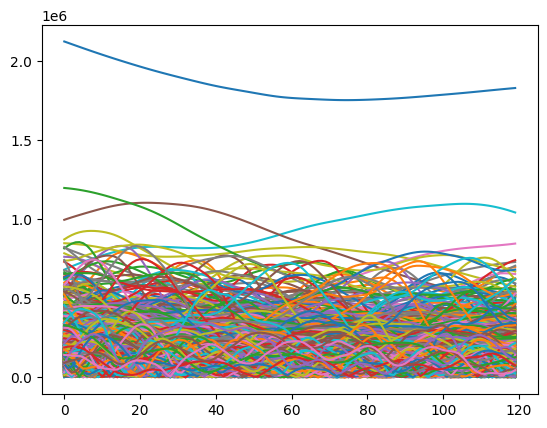

In [84]:
for key in model_data:
        #plt.plot(np.abs(data[key][0,:]))
        plt.plot(np.abs(model_data[key][0,:120]))



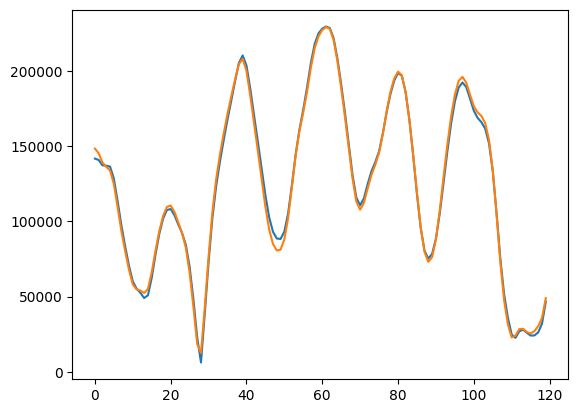

In [85]:
for t in range (model_data[key].shape[0]):
        #plt.plot(np.abs(data[key][0,:]))
        plt.plot(np.abs(model_data[key][t,:120]))



In [86]:
model_bls=[]
for key in model_data.keys():
    model_bls.append((key[0],key[1],'nn'))

    

In [87]:
pol='nn'
sel_bls=[]
unflagged_data_bls = [bl for bl in vissol_flags if not np.all(vissol_flags[bl]) and bl[2] == pol]
for key in unflagged_data_bls:
    if key in model_bls:
        sel_bls.append(key)

In [88]:
len(sel_bls)

271

In [89]:
hd.update(data=sol.vis)
hd.write_uvh5("redundant_cal_data_single_pol.uvh5", clobber=True)

File exists; clobbering


In [90]:
hd_cal= io.HERAData("redundant_cal_data_single_pol.uvh5")
hd_cal.read(sel_bls, frequencies=hdm.freqs)
redcal_data,_,_=hd_cal.build_datacontainers()

In [91]:
model_data_modi=copy.deepcopy(redcal_data)
for k in redcal_data.keys():
        model_data_modi[k]=np.array(model_data[(k[0],k[1],'yy')])

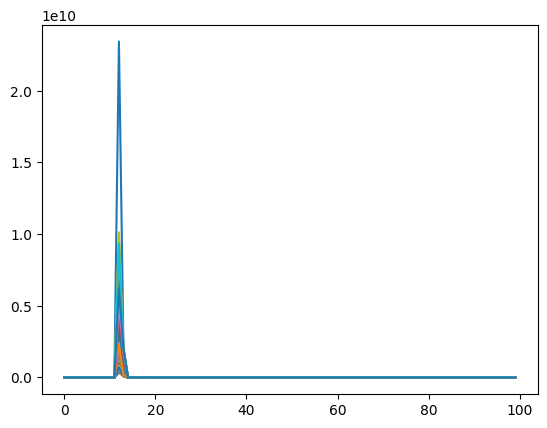

In [92]:
for key in sel_bls:
    #plt.plot(np.abs(data[key][0,:]))

    plt.plot((np.abs(sol.vis[key])[0,:])[:100])

In [93]:
gain_cal_pol={}
for k in sol.gains:
    if k[1]=='Jnn':
        gain_cal_pol[k]=sol.gains[k]

rc_flags = {k: np.zeros_like(gain_cal_pol[k], dtype=bool) for k in gain_cal_pol}  
noise_wgts = {k: np.ones_like(redcal_data[k], dtype=float)  for k in redcal_data}
# calibration with lincal gains
calibrated_data = copy.deepcopy(redcal_data)

In [94]:
abscal_gains = abscal.post_redcal_abscal(model_data_modi, calibrated_data, noise_wgts, rc_flags, verbose=False)

In [95]:
calibrated_data_test = copy.deepcopy(redcal_data)
abscal.calibrate_in_place(calibrated_data_test,abscal_gains)

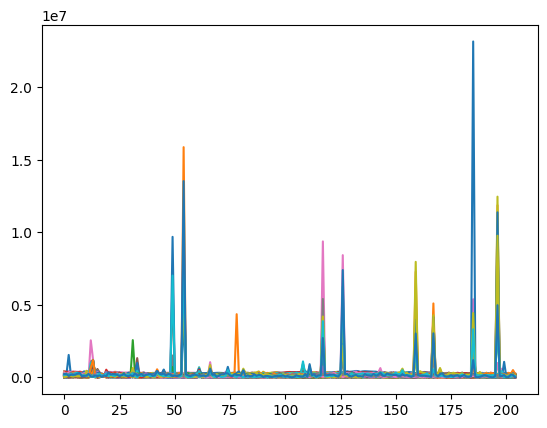

In [99]:
for key in redcal_data:
        #plt.plot(np.abs(data[key][0,:]))
        plt.plot(np.abs(calibrated_data[key][0,:]))

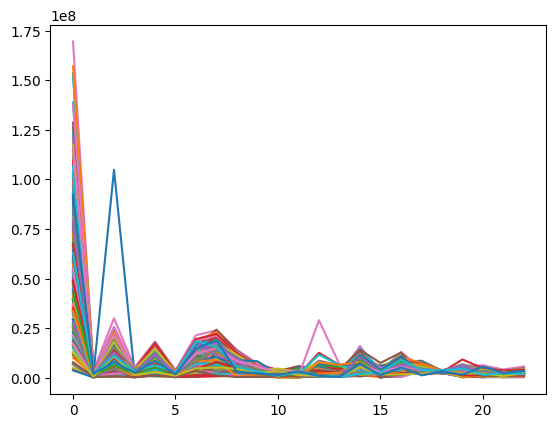

In [103]:
for key in redcal_data:
        #plt.plot(np.abs(data[key][0,:]))
        plt.plot(np.abs(calibrated_data_test[key][0,:23]))

In [102]:

data_flagged_redcal=copy.deepcopy(calibrated_data_test)
for bls in data_flagged_redcal:
    if bls in sol.vis:
        if not overall_class[utils.split_bl(bls)[0]]=='bad':
            data_flagged_redcal[bls]=np.array(calibrated_data_test[bls])
            data_flagged_redcal[bls][np.where(rfi_flags==True)]=np.nan
                
            
        else:
           
            data_flagged_redcal[bls]=np.ones(sol.vis[bls].shape)*np.nan

NameError: name 'rfi_flags' is not defined

In [66]:
abscal_start=time.time()
DO_FULL_ABSCAL = True

if DO_FULL_ABSCAL:
    abscal_meta = {}
    for pol in ['ee', 'nn']:
        print(f'Performing absolute phase gradient calibration of {pol}-polarized visibility solutions...')
        
        # load matching times and baselines
        unflagged_data_bls = [bl for bl in vissol_flags if not np.all(vissol_flags[bl]) and bl[2] == pol]
        model_bls = copy.deepcopy(hdm.bls)
        model_antpos = hdm.data_antpos
        if len(matched_model_files) > 1:  # in this case, it's a dictionary
            model_bls = list(set([bl for bls in list(hdm.bls.values()) for bl in bls]))
            model_antpos = {ant: pos for antpos in hdm.data_antpos.values() for ant, pos in antpos.items()}
        data_bls, model_bls, data_to_model_bl_map = abscal.match_baselines(unflagged_data_bls, model_bls, data.antpos, model_antpos=model_antpos, 
                                                                         pols=[pol], data_is_redsol=True, model_is_redundant=True, tol=1.0,
                                                                         min_bl_cut=ABSCAL_MIN_BL_LEN, max_bl_cut=ABSCAL_MAX_BL_LEN, verbose=True)
        model, model_flags, _ = io.partial_time_io(hdm, np.unique([d2m_time_map[time] for time in data.times]), bls=model_bls)
        model_bls = [data_to_model_bl_map[bl] for bl in data_bls]
        
        # rephase model to match in lsts
        model_blvecs = {bl: model.antpos[bl[0]] - model.antpos[bl[1]] for bl in model.keys()}
        utils.lst_rephase(model, model_blvecs, model.freqs, data.lsts - model.lsts,
                          lat=hdm.telescope_location_lat_lon_alt_degrees[0], inplace=True)

        # run abscal and apply 
        abscal_meta[pol], delta_gains = abscal.complex_phase_abscal(sol.vis, model, sol.reds, data_bls, model_bls)
        
        # apply gains
        sol.gains = {antpol : g * delta_gains.get(antpol, 1) for antpol, g in sol.gains.items()}
        apply_cal.calibrate_in_place(sol.vis, delta_gains)            
     
    del model, model_flags, delta_gains
    malloc_trim()    
    
    print(f'Finished absolute calibration of tip-tilt phase slopes in {(time.time() - abscal_start) / 60:.2f} minutes.')


Performing absolute phase gradient calibration of ee-polarized visibility solutions...
Selected 214 data baselines and 214 model baselines to load.
Performing absolute phase gradient calibration of nn-polarized visibility solutions...
Selected 267 data baselines and 267 model baselines to load.
Finished absolute calibration of tip-tilt phase slopes in 0.39 minutes.


In [67]:
if DO_FULL_ABSCAL and CALIBRATE_CROSS_POLS:
    cross_pol_cal_start = time.time()

    # Compute reds for good antennas 
    cross_reds = redcal.get_reds(hd.data_antpos, pols=['en', 'ne'])        
    cross_reds = redcal.filter_reds(cross_reds, ex_ants=overall_class.bad_ants, pols=['en', 'ne'], antpos=hd.antpos, **fr_settings)    
    unflagged_data_bls = [red[0] for red in cross_reds]

    # Get cross-polarized model visibilities
    model_bls = copy.deepcopy(hdm.bls)
    model_antpos = hdm.data_antpos
    if len(matched_model_files) > 1:  # in this case, it's a dictionary
        model_bls = list(set([bl for bls in list(hdm.bls.values()) for bl in bls]))
        model_antpos = {ant: pos for antpos in hdm.data_antpos.values() for ant, pos in antpos.items()}

    data_bls, model_bls, data_to_model_bl_map = abscal.match_baselines(unflagged_data_bls, model_bls, data.antpos, model_antpos=model_antpos, 
                                                                     pols=['en', 'ne'], data_is_redsol=False, model_is_redundant=True, tol=1.0,
                                                                     min_bl_cut=ABSCAL_MIN_BL_LEN, max_bl_cut=ABSCAL_MAX_BL_LEN, verbose=True)
    
    model, model_flags, _ = io.partial_time_io(hdm, np.unique([d2m_time_map[time] for time in data.times]), bls=model_bls)
    model_bls = [data_to_model_bl_map[bl] for bl in data_bls]

    # rephase model to match in lsts
    model_blvecs = {bl: model.antpos[bl[0]] - model.antpos[bl[1]] for bl in model.keys()}
    utils.lst_rephase(model, model_blvecs, model.freqs, data.lsts - model.lsts, lat=hdm.telescope_location_lat_lon_alt_degrees[0], inplace=True)

    # Solve for polarization phase offset
    weighted_sum = np.zeros(data.shape, dtype=complex)
    
    for red in cross_reds:
        data_bl = red[0]
        if data_bl in data_to_model_bl_map:
            # load data and model visibilities
            model_bl = data_to_model_bl_map[data_bl]
            wgts_here = np.sum([
                np.logical_not(omni_flags[utils.split_bl(bl)[0]] | omni_flags[utils.split_bl(bl)[1]])
                for bl in red
            ], axis=0)
            data_here = np.nanmean([
                np.where(
                    omni_flags[utils.split_bl(bl)[0]] | omni_flags[utils.split_bl(bl)[1]],
                    np.nan, sol.calibrate_bl(bl, data[bl])
                ) 
                for bl in red
            ], axis=0)
            
            # Compute data-model product 
            model_data_prod = model[model_bl].conj() * data_here
            
            if data_bl[-1] == 'ne':
                model_data_prod = np.conj(model_data_prod)

            weighted_sum += wgts_here * model_data_prod

    delta = np.where(np.isfinite(weighted_sum), np.angle(weighted_sum), 0.0)
    delta_gains = {
        antpol: np.exp(1j * delta) if antpol[-1] == 'Jee'
        else np.ones_like(delta)
        for antpol in sol.gains
    }
    
    # apply gains
    # \Delta = \phi_e - \phi_n, where V_{en}^{cal} = V_{en}^{uncal} * e^{i \Delta} 
    # and V_{ne}^{cal} = V_{ne}^{uncal} * e^{-i \Delta}
    sol.gains = {antpol: g * delta_gains[antpol] for antpol, g in sol.gains.items()}
    apply_cal.calibrate_in_place(sol.vis, delta_gains)
    del hdm, model, model_flags, delta_gains
    print(f'Finished relative polarized phase calibration in {(time.time() - cross_pol_cal_start) / 60:.2f} minutes.')

In [68]:
def redundant_group_plot():
    if np.all([ant in overall_class.bad_ants for ant in ants]):
        print('All antennas classified as bad. Nothing to plot.')
        return
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 6), dpi=100, sharex='col', sharey='row', gridspec_kw={'hspace': 0, 'wspace': 0})
    for i, pol in enumerate(['ee', 'nn']):
        reds_here = redcal.get_reds(hd.data_antpos, pols=[pol], pol_mode='1pol')
        red = sorted(redcal.filter_reds(reds_here, ex_ants=overall_class.bad_ants), key=len, reverse=True)[0]
        rc_data = {bl: sol.calibrate_bl(bl, data[bl]) for bl in red}
        for bl in red:
            axes[0, i].plot(data.freqs/1e6, np.angle(rc_data[bl][0]), alpha=.5, lw=.5)
            axes[1, i].semilogy(data.freqs/1e6, np.abs(rc_data[bl][0]), alpha=.5, lw=.5)
        axes[0, i].plot(data.freqs / 1e6, np.angle(sol.vis[red[0]][0]), lw=1, c='k')
        axes[1, i].semilogy(data.freqs / 1e6, np.abs(sol.vis[red[0]][0]), lw=1, c='k', label=f'Baseline Group:\n{red[0]}')
        axes[1, i].set_xlabel('Frequency (MHz)')
        axes[1, i].legend(loc='upper right')
    axes[0, 0].set_ylabel('Visibility Phase (radians)')
    axes[1, 0].set_ylabel('Visibility Amplitude (Jy)')
    plt.tight_layout()


In [69]:
def abscal_degen_plot():
    if DO_FULL_ABSCAL:
        fig, axes = plt.subplots(3, 1, figsize=(14, 6), dpi=100, sharex=True, gridspec_kw={'hspace': .05})

        for ax, pol in zip(axes[:2], ['ee', 'nn']):
            for kk in range(abscal_meta[pol]['Lambda_sol'].shape[-1]):
                ax.plot(hd.freqs[~rfi_flags[0]] * 1e-6, abscal_meta[pol]['Lambda_sol'][0, ~rfi_flags[0], kk], '.', ms=1, label=f"Component {kk}")

            ax.set_ylim(-np.pi-0.5, np.pi+0.5)
            ax.set_xlabel('Frequency (MHz)')
            ax.set_ylabel('Phase Gradient\nVector Component')
            ax.legend(markerscale=20, title=f'{pol}-polarization', loc='lower right')
            ax.grid()
            
        for pol, color in zip(['ee', 'nn'], ['b', 'r']):
            axes[2].plot(hd.freqs[~rfi_flags[0]]*1e-6, abscal_meta[pol]['Z_sol'].real[0, ~rfi_flags[0]], '.', ms=1, label=pol, color=color)
        axes[2].set_ylim(-.25, 1.05)
        axes[2].set_ylabel('Re[Z($\\nu$)]')
        axes[2].legend(markerscale=20, loc='lower right')
        axes[2].grid()            
        plt.tight_layout()


In [70]:
def polarized_gain_phase_plot():
    if CALIBRATE_CROSS_POLS and DO_FULL_ABSCAL:
        plt.figure(figsize=(14, 4), dpi=100)
        for i, time in enumerate(data.times):
            plt.plot(data.freqs / 1e6, np.where(rfi_flags[i], np.nan, delta[i, :]), '.', ms=1.5, label=f'{time:.6f}')
        plt.ylim(-np.pi-0.5, np.pi+0.5)
        plt.xlabel('Frequency (MHz)')
        plt.ylabel('Relative Phase $\Delta \ (\phi_{ee} - \phi_{nn})$')
        plt.grid()
        plt.legend()


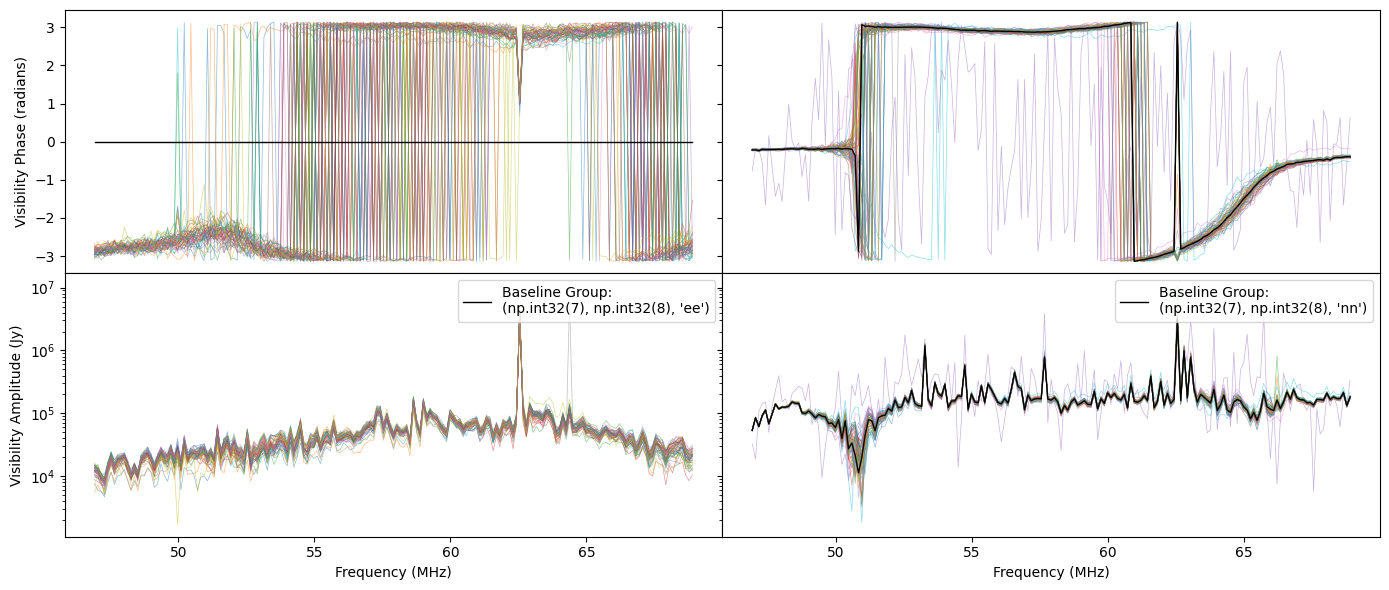

In [71]:
if PLOT: redundant_group_plot()

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


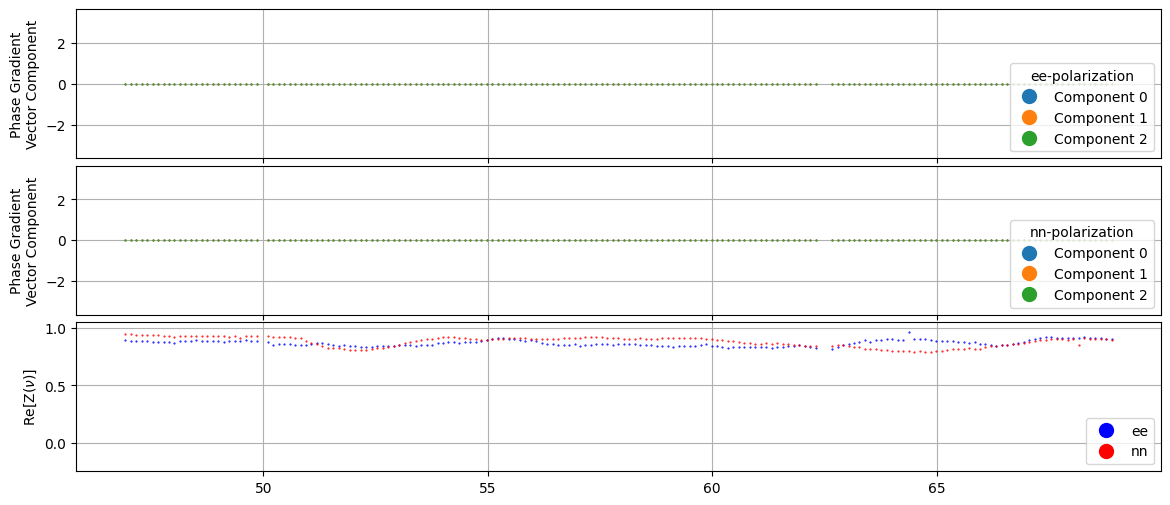

In [72]:
if PLOT: abscal_degen_plot()

In [73]:
if PLOT: polarized_gain_phase_plot()

In [74]:
expand_start = time.time()
expanded_reds = redcal.get_reds(hd.data_antpos, pols=['ee', 'nn'], pol_mode='2pol')
sol.vis.build_red_keys(expanded_reds)
redcal.expand_omni_gains(sol, expanded_reds, data, chisq_per_ant=meta['chisq_per_ant'])
if not np.all([ant in overall_class.bad_ants for ant in ants]):
    redcal.expand_omni_vis(sol, expanded_reds, data)

# Replace near-zeros in gains and infs/nans in gains/sols
for ant in sol.gains:
    zeros_in_gains = np.isclose(sol.gains[ant], 0)
    if ant in omni_flags:
        omni_flags[ant][zeros_in_gains] = True
    sol.gains[ant][zeros_in_gains] = 1.0 + 0.0j
sol.make_sol_finite()
malloc_trim()
print(f'Finished expanding gain solution in {(time.time() - expand_start) / 60:.2f} minutes.')

Finished expanding gain solution in 0.04 minutes.


In [75]:
def array_chisq_plot(include_outriggers=True):
    if np.all([ant in overall_class.bad_ants for ant in ants]):
        print('All antennas classified as bad. Nothing to plot.')
        return    
    
    def _chisq_subplot(ants, size=250):
        fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=100)
        for ax, pol in zip(axes, ['ee', 'nn']):
            ants_to_plot = set([ant for ant in meta['chisq_per_ant'] if utils.join_pol(ant[1], ant[1]) == pol and (ant[0] in ants)])
            cspas = np.array([np.nanmean(np.where(rfi_flags, np.nan, meta['chisq_per_ant'][ant])) for ant in ants_to_plot])
            xpos = [hd.antpos[ant[0]][0] for ant in ants_to_plot]
            ypos = [hd.antpos[ant[0]][1] for ant in ants_to_plot]
            scatter = ax.scatter(xpos, ypos, s=size, c=cspas, lw=.25, edgecolors=np.where(np.isfinite(cspas) & (cspas > 0), 'none', 'k'), 
                                 norm=matplotlib.colors.LogNorm(vmin=1, vmax=oc_cspa_suspect[1]))
            for ant in ants_to_plot:
                ax.text(hd.antpos[ant[0]][0], hd.antpos[ant[0]][1], ant[0], va='center', ha='center', fontsize=8,
                        c=('r' if ant in overall_class.bad_ants else 'w'))
            plt.colorbar(scatter, ax=ax, extend='both')
            ax.axis('equal')
            ax.set_xlabel('East-West Position (meters)')
            ax.set_ylabel('North-South Position (meters)')
            ax.set_title(f'{pol}-pol $\\chi^2$ / Antenna (Red is Flagged)')
        plt.tight_layout()    
    
    _chisq_subplot([ant for ant in hd.data_ants if ant < 320])
    outriggers = [ant for ant in hd.data_ants if ant >= 320]    
    if include_outriggers & (len(outriggers) > 0):
        _chisq_subplot([ant for ant in hd.data_ants if ant >= 320], size=400)



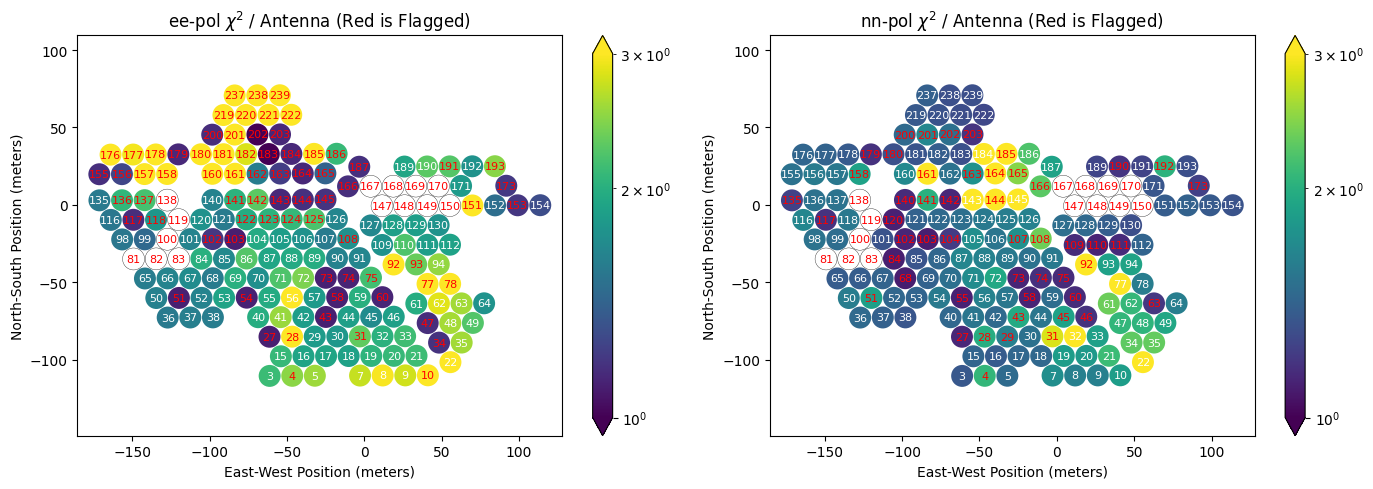

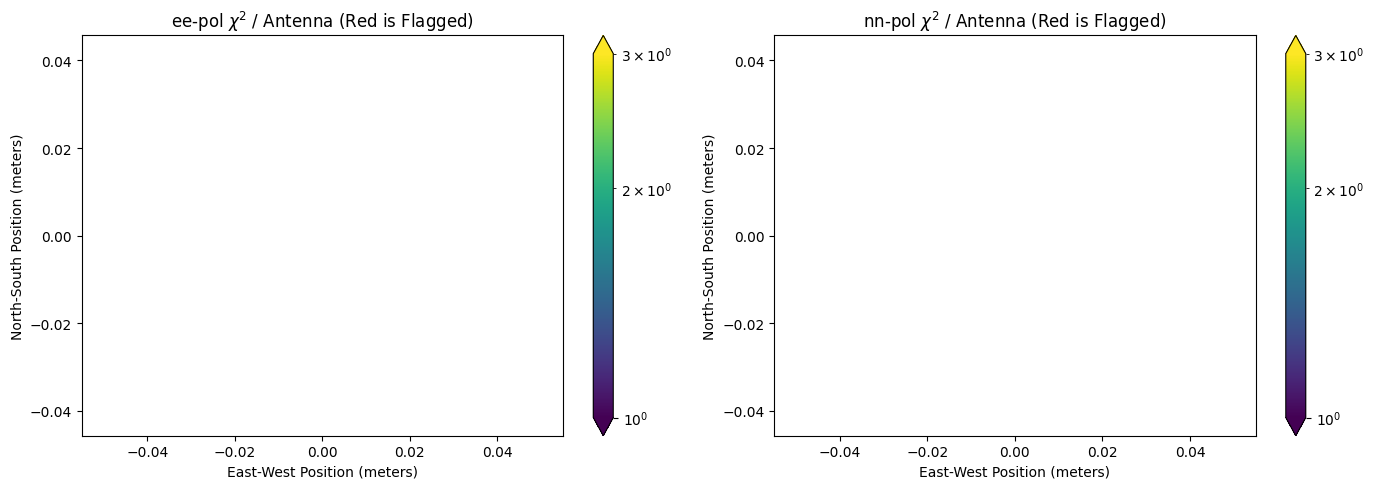

In [76]:
if PLOT: array_chisq_plot(include_outriggers=(not OC_SKIP_OUTRIGGERS))

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


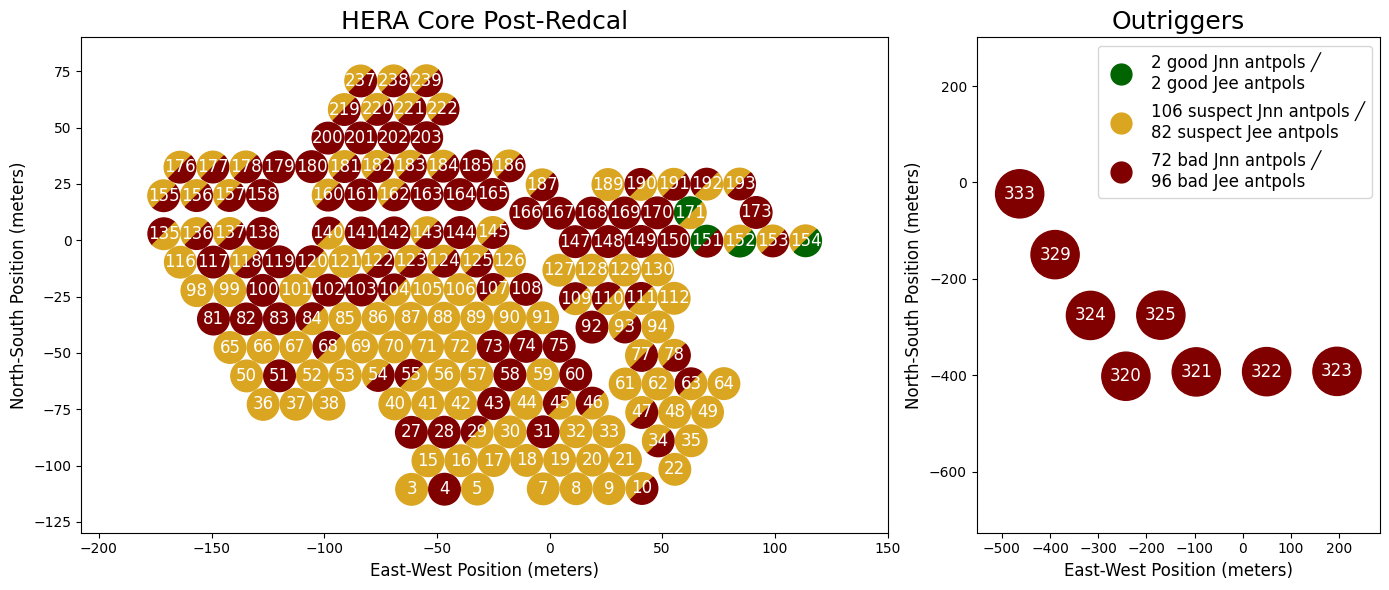

In [77]:
if PLOT: array_class_plot(overall_class, extra_label=" Post-Redcal")